<a href="https://colab.research.google.com/github/MithunSrinivas28/wafer-defect-ai/blob/addfeature/Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BLOCK 1 — IMPORTS

In [124]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

In [127]:
MODEL_PATH = "/content/drive/MyDrive/wafer_xai2_model.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("Model Loaded ✅")
model.summary()


Model Loaded ✅


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 576)            │         2,304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,168,394 (4.46 MB)

 Trainable params: 76,040 (297.03 KB)

 Non-trainable params: 940,272 (3.59 MB)

 Optimizer params: 152,082 (594.07 KB)

 BLOCK 3 — CLASS NAMES

In [128]:
class_names = [
    'bridge','clean','cmp','crack',
    'ler','others','open','vias'
]


BLOCK 4 — LAST CONV LAYER (FIXED)

In [129]:
LAST_CONV_LAYER = "expanded_conv_10_project"


print("Using Conv Layer:", LAST_CONV_LAYER)


Using Conv Layer: expanded_conv_10_project


BLOCK 5 — IMAGE LOADER (GRAY → RGB)

In [130]:
def load_image(path):

    img = tf.keras.utils.load_img(
        path,
        target_size=(224,224),
        color_mode="grayscale"
    )

    arr = tf.keras.utils.img_to_array(img)

    arr = arr / 255.0
    arr = np.repeat(arr, 3, axis=-1)

    arr = np.expand_dims(arr, axis=0)

    return arr




In [131]:
dummy = tf.zeros((1,224,224,3))
model(dummy, training=False)
print("Model built ✅")



Model built ✅


BLOCK 6 — PREDICTION + CONFIDENCE

In [132]:
def predict_image(img):

    logits = model.predict(img)[0]

    # NORMAL temperature (honest confidence)
    T = 1.0

    probs = np.exp(logits/T) / np.sum(np.exp(logits/T))
    idx = np.argmax(probs)

    print("\nPrediction:", class_names[idx])
    print("Confidence:", round(np.max(probs)*100,2), "%")

    return probs, idx




BLOCK 7 — BAR GRAPH (MATPLOTLIB OUTPUT)

In [133]:
def plot_probabilities(probs):

    plt.figure(figsize=(8,4))

    plt.bar(class_names, probs*100, color="skyblue")

    plt.xticks(rotation=45)
    plt.ylabel("Confidence (%)")
    plt.title("Prediction Probabilities")

    plt.grid(axis="y", alpha=0.3)
    plt.show()





In [134]:
IMG_PATH = "/content/open.png"   # change if needed

img = load_image(IMG_PATH)


BLOCK 8 — GRAD‑CAM GENERATOR

In [135]:
def make_gradcam(model, img):

    # Backbone
    backbone = model.layers[0]

    # Last conv layer
    conv_layer = backbone.get_layer(LAST_CONV_LAYER)

    # Conv output model
    conv_model = tf.keras.Model(
        backbone.input,
        conv_layer.output
    )

    with tf.GradientTape() as tape:

        # Forward pass
        conv_out = conv_model(img, training=False)

        # VERY IMPORTANT: tell TF to track this
        tape.watch(conv_out)

        preds = model(img, training=False)

        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    # Get gradients
    grads = tape.gradient(loss, conv_out)

    # Safety check (prevents crash)
    if grads is None:
        print("⚠️ Gradients are None. Using fallback heatmap.")
        return np.zeros((conv_out.shape[1], conv_out.shape[2]))

    # Pool gradients
    pooled = tf.reduce_mean(grads, axis=(0,1,2))

    conv_out = conv_out[0]

    # Heatmap
    heatmap = conv_out * pooled
    heatmap = tf.reduce_sum(heatmap, axis=-1)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)

    heatmap = (heatmap - tf.reduce_min(heatmap)) / (
        tf.reduce_max(heatmap) - tf.reduce_min(heatmap) + 1e-8
    )

    heatmap = np.power(heatmap.numpy(), 2.0)

    return heatmap


BLOCK 9 — SHOW GRAD‑CAM (MATPLOTLIB)


In [136]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def show_gradcam(heatmap, path):

    # Load original image
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    # Create colored heatmap ✅
    heatmap_color = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay
    final = cv2.addWeighted(img, 0.5, heatmap_color, 0.5, 0)


    # Show
    plt.figure(figsize=(6,6))
    plt.imshow(final)
    plt.axis("off")
    plt.title("Grad-CAM")
    plt.show()


BLOCK 10 — SELF‑LEARNING MODULE

In [137]:
SELF_LEARN_DIR = "/content/self_learning"

os.makedirs(SELF_LEARN_DIR, exist_ok=True)


def self_learn(img_path, probs, threshold=0.5):

    conf = np.max(probs)

    if conf < threshold:

        name = os.path.basename(img_path)

        save_path = os.path.join(
            SELF_LEARN_DIR,
            name
        )

        img = cv2.imread(img_path)
        cv2.imwrite(save_path, img)

        print("⚠️ Low confidence → Saved for retraining")
        print("Saved at:", save_path)

    else:
        print("High confidence → No save")


BLOCK 11 — FULL PIPELINE (RUN THIS)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Prediction: others
Confidence: 18.74 %
⚠️ Gradients are None. Using fallback heatmap.


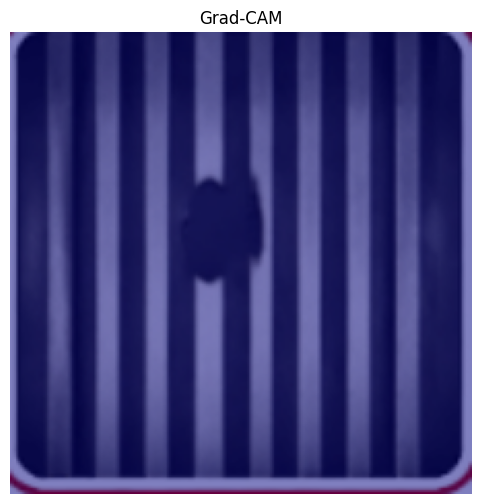

In [138]:
IMG_PATH = "/content/open.png"


img = load_image(IMG_PATH)

probs, idx = predict_image(img)

heatmap = make_gradcam(model, img)
show_gradcam(heatmap, IMG_PATH)


In [149]:
import numpy as np
import tensorflow as tf

y_pred = []

for images, labels in test_data:

    # ✅ Convert grayscale (1 channel) → RGB (3 channels)
    images_rgb = tf.repeat(images, 3, axis=-1)

    preds = model.predict(images_rgb)
    y_pred.extend(np.argmax(preds, axis=1))

unique, counts = np.unique(y_pred, return_counts=True)

print("Prediction counts per class:")
for u, c in zip(unique, counts):
    print(class_names[u], "→", c, "times")




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Prediction counts per class:
bridge → 32 times
cmp → 17 times
ler → 112 times
others → 76 times
open → 27 times


In [151]:
TRAIN_PATH = "/content/drive/MyDrive/Datasets/train"

train_data = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(224,224),
    color_mode="grayscale",
    batch_size=32,
    shuffle=True
)


Found 1032 files belonging to 8 classes.


In [147]:
TEST_PATH  = "/content/drive/MyDrive/Datasets/test"
test_data = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=(224,224),
    color_mode="grayscale",
    batch_size=32,
    shuffle=True
)


Found 264 files belonging to 8 classes.


In [152]:
y_true = []
for images, labels in train_data:
    y_true.extend(labels.numpy())

import numpy as np
unique, counts = np.unique(y_true, return_counts=True)

print("Training data distribution:")
for u, c in zip(unique, counts):
    print(class_names[u], "→", c)


Training data distribution:
bridge → 129
clean → 129
cmp → 129
crack → 129
ler → 129
others → 129
open → 129
vias → 129
